Weather Forecasting

01 Exploratory Data Analysis

A time-series project that forecasts hourly temperature at Jena, Germany from its own recent history (lags) and calendar features. We explore the series' trend, seasonality, and autocorrelation — the structure the forecasting models in notebook 03 will exploit.

In [26]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

In [27]:
df = utils.load_data("weather.csv")
print('rows:',len(df),'| from',df.date.min(),'to',df.date.max())
df.head()

rows: 17471 | from 2015-01-01 00:00:00 to 2016-12-31 23:00:00


,date,y
0,2015-01-01 00:00:00,2.113333
1,2015-01-01 01:00:00,2.173333
2,2015-01-01 02:00:00,1.958333
3,2015-01-01 03:00:00,1.836667
4,2015-01-01 04:00:00,2.238333


1. The series over time

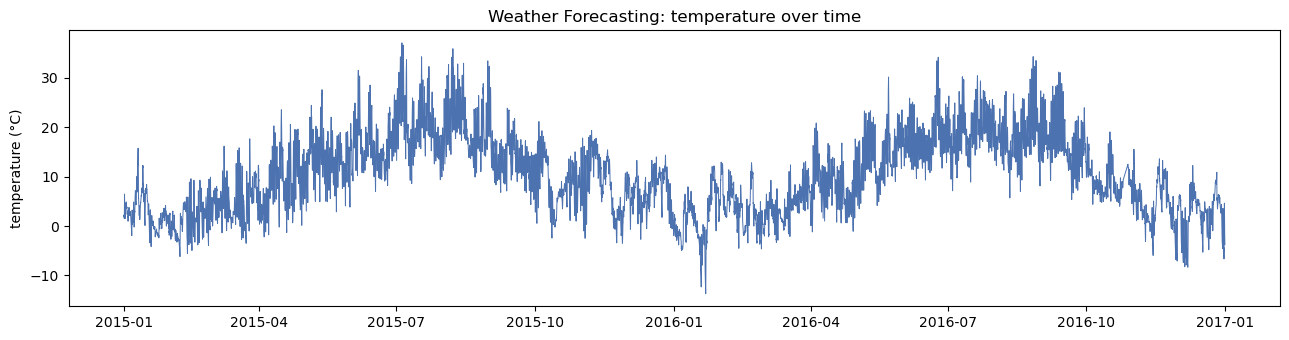

In [28]:
fig,ax=plt.subplots(figsize=(13,3.5))
ax.plot(df['date'],df['y'],lw=0.7,color='#4c72b0')
ax.set_title('Weather Forecasting: temperature over time'); ax.set_ylabel('temperature (°C)'); plt.tight_layout(); plt.show()

2. Distribution & summary

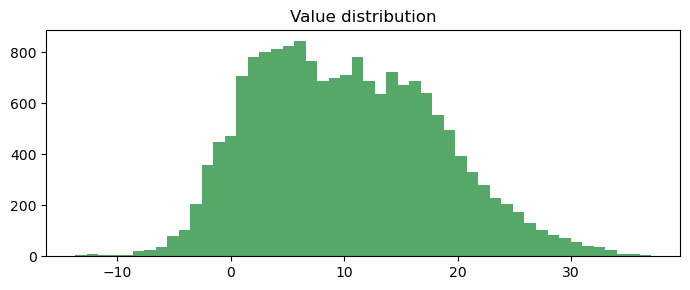

count    17471.00
mean        10.25
std          8.01
min        -13.69
25%          3.91
50%          9.70
75%         16.01
max         37.04


In [29]:
fig,ax=plt.subplots(figsize=(7,3))
ax.hist(df['y'],bins=50,color='#55a868'); ax.set_title('Value distribution'); plt.tight_layout(); plt.show()
print(df['y'].describe().round(2).to_string())

3. Trend (rolling mean)

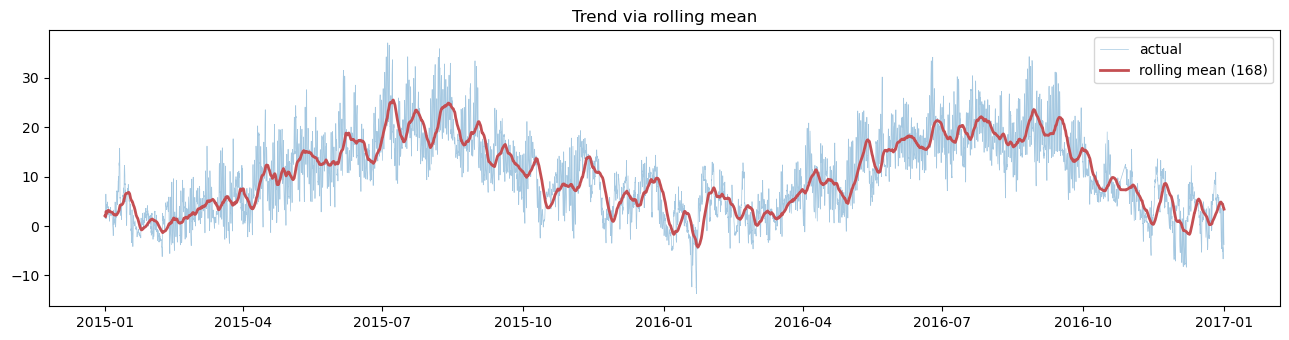

In [30]:
w=utils.SEASONAL_PERIOD* (7 if utils.FREQ=='D' else 7)
fig,ax=plt.subplots(figsize=(13,3.5))
ax.plot(df['date'],df['y'],lw=0.5,alpha=0.4,label='actual')
ax.plot(df['date'],df['y'].rolling(w,min_periods=1).mean(),color='#c44e52',lw=2,label=f'rolling mean ({w})')
ax.legend(); ax.set_title('Trend via rolling mean'); plt.tight_layout(); plt.show()

4. Seasonal decomposition (STL)

STL splits the series into trend + seasonal + residual components — exposing a very strong daily cycle (warm afternoons, cool nights) plus an annual season.

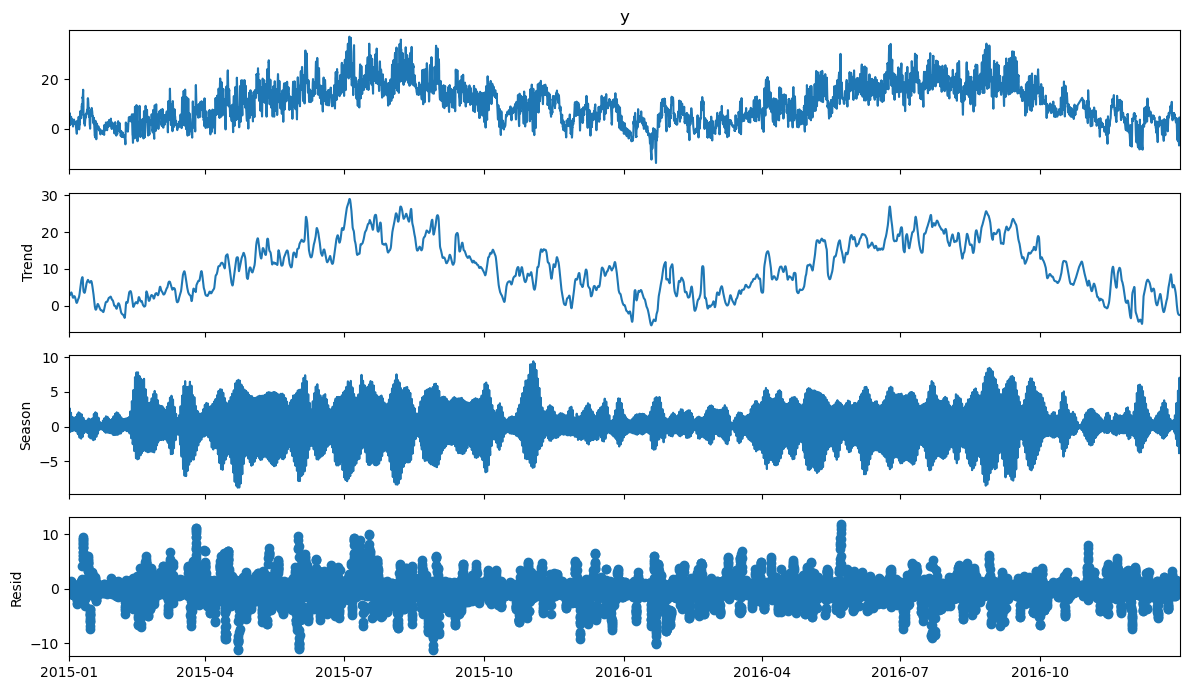

In [31]:
from statsmodels.tsa.seasonal import STL
s=df.set_index('date')['y'].asfreq(utils.FREQ).interpolate()
res=STL(s,period=utils.SEASONAL_PERIOD,robust=True).fit()
fig=res.plot(); fig.set_size_inches(12,7); plt.tight_layout(); plt.show()

5. Seasonal profile (by hour)

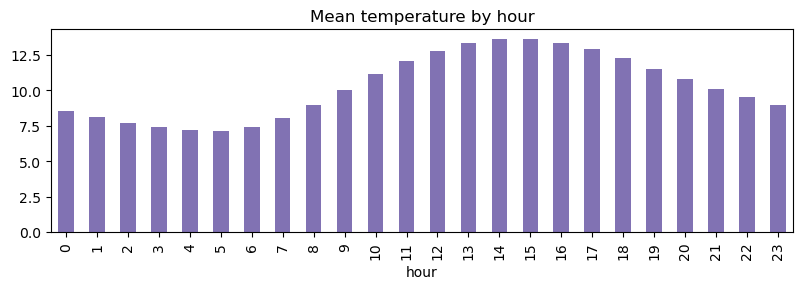

In [32]:
prof=df.assign(hour=df['date'].dt.hour).groupby('hour')['y'].mean()
fig,ax=plt.subplots(figsize=(8,3)); prof.plot(kind='bar',ax=ax,color='#8172b3'); ax.set_title('Mean temperature by hour'); plt.tight_layout(); plt.show()

6. Autocorrelation (ACF)

How strongly each value correlates with its past — the spikes show which lags are informative features.

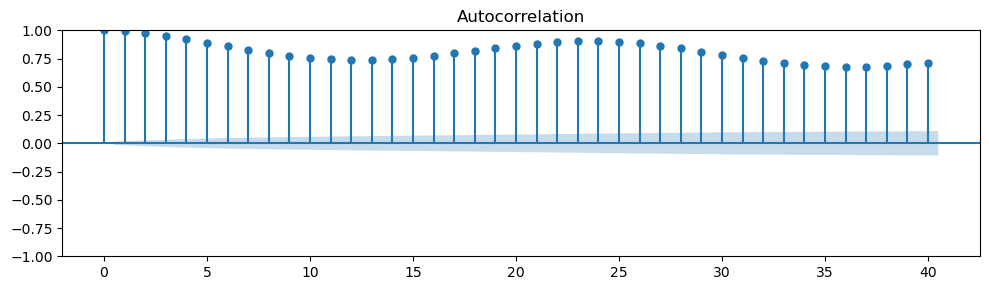

In [33]:
from statsmodels.graphics.tsaplots import plot_acf
fig,ax=plt.subplots(figsize=(10,3))
plot_acf(df['y'].dropna(),lags=min(40,len(df)//2-1),ax=ax); plt.tight_layout(); plt.show()

7. Summary

- The series shows a very strong daily cycle (warm afternoons, cool nights) plus an annual season.
- Strong autocorrelation at short lags and at the daily (24-hour) period justifies lag + rolling + calendar features (built in notebook 02).
- Notebook 03 forecasts with a chronological split and benchmarks ML models against naive baselines.

02 Feature Engineering & Split

Time series can't be shuffled. We build lag features (past values), rolling mean/std, and calendar features, then split chronologically (train on the past, test on the most recent slice).

In [36]:
import pandas as pd
import utils
df=utils.load_data("weather.csv")
print('raw rows:',len(df))

raw rows: 17471


1. Build features (lags + rolling + calendar)

In [37]:
feat=utils.build_features(df)
print('featured rows:',len(feat),'| features:',len(utils.feature_columns(feat)))
print('feature columns:',utils.feature_columns(feat))
feat.head()

featured rows: 17303 | features: 16
feature columns: ['month', 'day', 'dayofweek', 'dayofyear', 'is_weekend', 'hour', 'lag_1', 'lag_2', 'lag_3', 'lag_24', 'lag_48', 'lag_168', 'rollmean_24', 'rollstd_24', 'rollmean_168', 'rollstd_168']


,date,y,month,day,dayofweek,dayofyear,is_weekend,hour,lag_1,lag_2,lag_3,lag_24,lag_48,lag_168,rollmean_24,rollstd_24,rollmean_168,rollstd_168
0,2015-01-08 00:00:00,0.540000,1,8,3,8,0,0,0.278333,-0.205000,0.598333,0.811667,0.096667,2.113333,1.907708,1.464462,2.237371,1.428919
1,2015-01-08 01:00:00,0.693333,1,8,3,8,0,1,0.540000,0.278333,-0.205000,1.266667,-0.048333,2.173333,1.896389,1.474319,2.228006,1.434880
2,2015-01-08 02:00:00,1.540000,1,8,3,8,0,2,0.693333,0.540000,0.278333,1.151667,-0.198333,1.958333,1.872500,1.489533,2.219196,1.439753
3,2015-01-08 03:00:00,1.643333,1,8,3,8,0,3,1.540000,0.693333,0.540000,0.953333,-0.361667,1.836667,1.888681,1.483459,2.216706,1.440568
4,2015-01-08 04:00:00,1.886667,1,8,3,8,0,4,1.643333,1.540000,0.693333,0.780000,-0.438333,2.238333,1.917431,1.471179,2.215556,1.440951


2. Chronological train/test split

In [38]:
train,test=utils.chronological_split(feat,test_frac=0.2)
print('train:',len(train),'(',train.date.min().date(),'->',train.date.max().date(),')')
print('test :',len(test),'(',test.date.min().date(),'->',test.date.max().date(),')')

train: 13842 ( 2015-01-08 -> 2016-08-06 )
test : 3461 ( 2016-08-06 -> 2016-12-31 )


3. Save featured data

In [41]:
feat.to_csv('featured.csv',index=False)
print('saved featured.csv',feat.shape)

saved featured.csv (17303, 18)


03 Model Building

We forecast on a chronological hold-out and compare naive and seasonal-naive baselines against seven regressors (Linear, Ridge, Lasso, Decision Tree, Random Forest, Gradient Boosting, KNN) on MAE / RMSE / MAPE / R². Beating the seasonal-naive baseline is the real bar. All numbers are produced by running the code.

In [42]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')
%matplotlib inline
import utils

In [45]:
df=utils.load_data("weather.csv")
feat=utils.build_features(df)
res,train,test,preds=utils.run_all(feat,test_frac=0.2)
print('test points:',len(test))

test points: 3461


1. Model comparison (sorted by RMSE)

In [47]:
res

,model,MAE,RMSE,MAPE,R2
0,Linear Regression,0.392,0.566,15.55,0.9953
1,Ridge,0.392,0.566,15.56,0.9953
2,Random Forest,0.413,0.586,18.71,0.9950
3,Lasso,0.430,0.617,18.59,0.9944
4,Gradient Boosting,0.464,0.641,24.58,0.9940
5,Decision Tree,0.522,0.743,21.65,0.9919
6,KNN,1.944,2.518,68.17,0.9069
7,Seasonal Naive,2.367,3.057,104.25,0.8628
8,Naive,12.072,13.909,834.58,-1.8412


2. RMSE chart

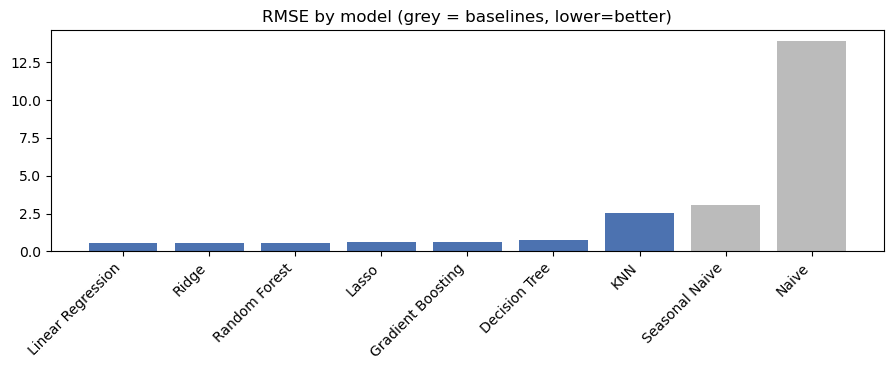

In [48]:
fig,ax=plt.subplots(figsize=(9,3.8))
ax.bar(res['model'],res['RMSE'],color=['#bbb' if m in ('Naive','Seasonal Naive') else '#4c72b0' for m in res['model']])
ax.set_title('RMSE by model (grey = baselines, lower=better)'); plt.xticks(rotation=45,ha='right'); plt.tight_layout(); plt.show()

3. Forecast vs actual (best model)

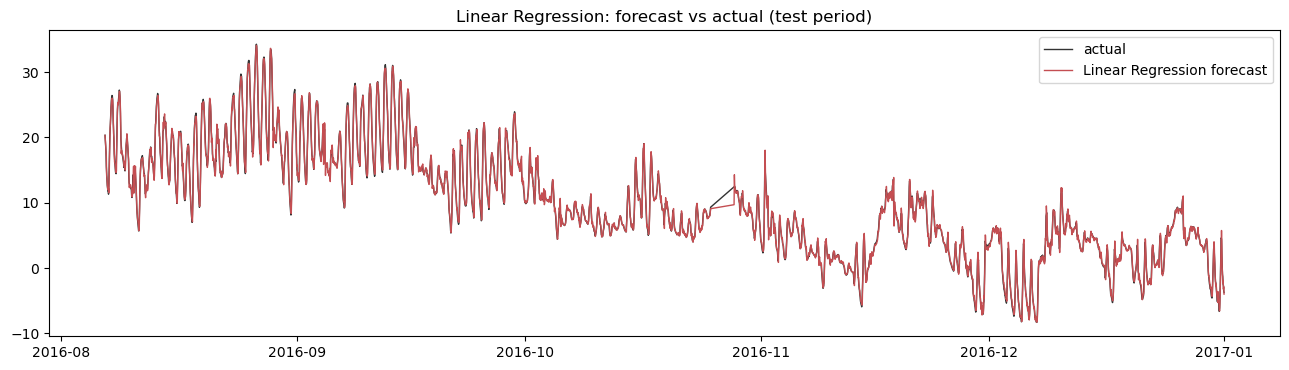

In [49]:
best=[m for m in res['model'] if m not in ('Naive','Seasonal Naive')]
best=res[res['model'].isin(best)].iloc[0]['model']
fig,ax=plt.subplots(figsize=(13,3.8))
ax.plot(test['date'],test['y'].values,label='actual',color='#333',lw=1)
ax.plot(test['date'],preds[best],label=f'{best} forecast',color='#c44e52',lw=1)
ax.legend(); ax.set_title(f'{best}: forecast vs actual (test period)'); plt.tight_layout(); plt.show()

4. Feature importance (best tree model)

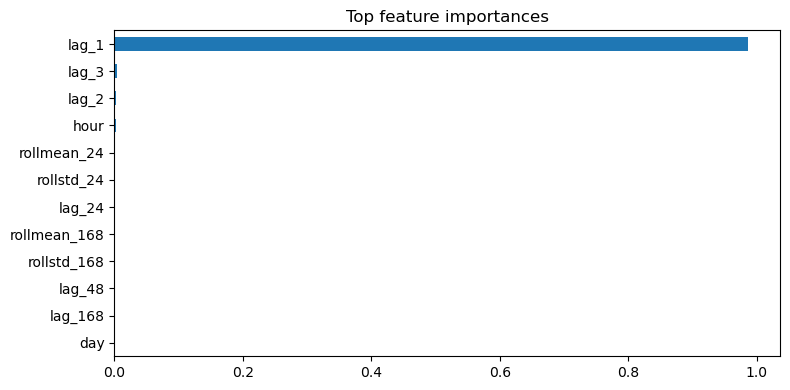

In [50]:
from sklearn.ensemble import RandomForestRegressor
cols=utils.feature_columns(feat)
rf=RandomForestRegressor(n_estimators=200,random_state=42,n_jobs=-1).fit(train[cols],train['y'])
imp=pd.Series(rf.feature_importances_,index=cols).sort_values(ascending=False).head(12)
fig,ax=plt.subplots(figsize=(8,4)); imp[::-1].plot(kind='barh',ax=ax); ax.set_title('Top feature importances'); plt.tight_layout(); plt.show()

5. Summary & takeaways

The results table and forecast plot above are the real, executed numbers (see the project README for the headline figures). The key question for any forecaster is whether it beats the seasonal-naive baseline — lag and calendar features let the ML models capture the trend and seasonality this series exhibits.